In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 100

units = np.random.randint(200, 600, n)
daily_usage = units / 30
occupants = np.random.randint(2, 7, n)
ac_hours = np.random.randint(2, 12, n)
appliances = np.random.randint(5, 20, n)

bill = (
    units * 6
    + occupants * 50
    + ac_hours * 40
    + appliances * 20
    + np.random.randint(-200, 200, n)
)

df = pd.DataFrame({
    "Units_Consumed": units,
    "Avg_Daily_Usage": daily_usage,
    "Num_Occupants": occupants,
    "AC_Usage_Hours": ac_hours,
    "Appliance_Count": appliances,
    "Electricity_Bill": bill
})

df.to_csv("electricity_bill_dataset.csv", index=False)

print(df.head())

   Units_Consumed  Avg_Daily_Usage  Num_Occupants  AC_Usage_Hours  \
0             302        10.066667              6               2   
1             548        18.266667              6               3   
2             470        15.666667              2               3   
3             306        10.200000              2               7   
4             271         9.033333              2               8   

   Appliance_Count  Electricity_Bill  
0                5              2264  
1               16              3847  
2               15              3460  
3                7              2419  
4               10              2445  


In [17]:
import pandas as pd

data = pd.read_csv("electricity_bill_dataset.csv")

print(data.shape)
data.head()

(100, 6)


,Units_Consumed,Avg_Daily_Usage,Num_Occupants,AC_Usage_Hours,Appliance_Count,Electricity_Bill
0,302,10.066667,6,2,5,2264
1,548,18.266667,6,3,16,3847
2,470,15.666667,2,3,15,3460
3,306,10.200000,2,7,7,2419
4,271,9.033333,2,8,10,2445


In [18]:
print("Total Rows:", len(data))
print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Total Rows: 100
Training Rows: 80
Testing Rows: 20


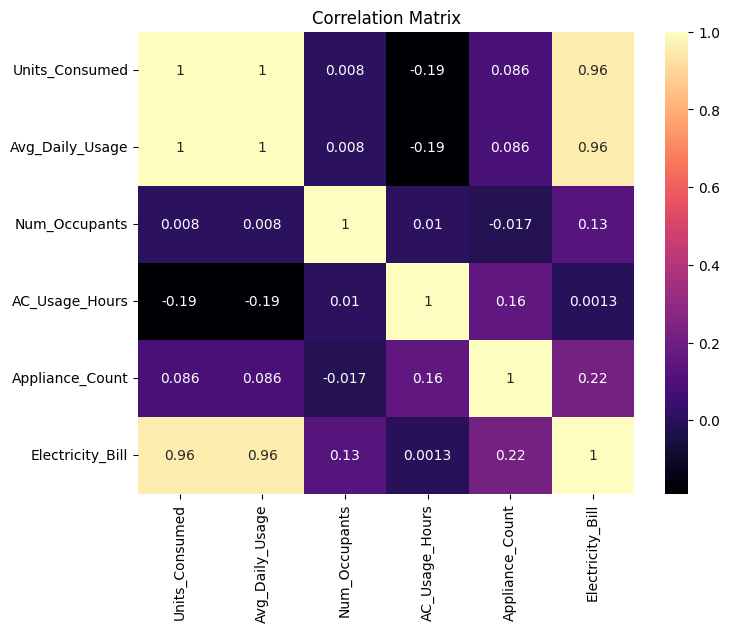

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='magma'
)

plt.title("Correlation Matrix")
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

X = data[['Units_Consumed',
          'Avg_Daily_Usage',
          'Num_Occupants',
          'AC_Usage_Hours',
          'Appliance_Count']]

y = data['Electricity_Bill']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MSE:", metrics.mean_squared_error(y_test, pred))

accuracy = model.score(X_test, y_test)
print("R² Score:", accuracy)

MSE: 14534.346061937318
R² Score: 0.9713488009716075
